In [2]:
import pathlib
import numpy as np
import pandas as pd

import Bio
import Bio.Seq
import Bio.SeqIO

import pysam


import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data_dir = pathlib.Path("../data/scratch/Oct22")

In [42]:
samples = pd.read_csv(data_dir / "Samples.csv")
samples[["parent", "category"]] = samples.Bio_sample.str.split("_", expand=True)
samples["frac_kept"] = samples.num_kept / samples.num_sequences
samples.set_index("Barcode", inplace=True)
samples

,Bio_sample,num_sequences,num_kept,parent,category,frac_kept
Barcode,,,,,,
bcAd1036T,1VH_H,128289,76325,1VH,H,0.594946
bcAd1037T,1VH_P,96102,53661,1VH,P,0.558375
bcAd1039T,1VH_L,164717,88896,1VH,L,0.539689
bcAd1040T,1VH_N,124708,60931,1VH,N,0.488589
bcAd1043T,2L_H,99077,46085,2L,H,0.465143
bcAd1044T,2L_P,38950,16677,2L,P,0.428164
bcAd1045T,2L_L,177951,80499,2L,L,0.452366
bcAd1046T,2L_N,150144,61207,2L,N,0.407655
bcAd1047T,3VRL_H,90548,50976,3VRL,H,0.562972


In [43]:
samples_melt = pd.melt(samples, id_vars=["parent", "category"], 
        value_vars=["num_sequences", "num_kept"])

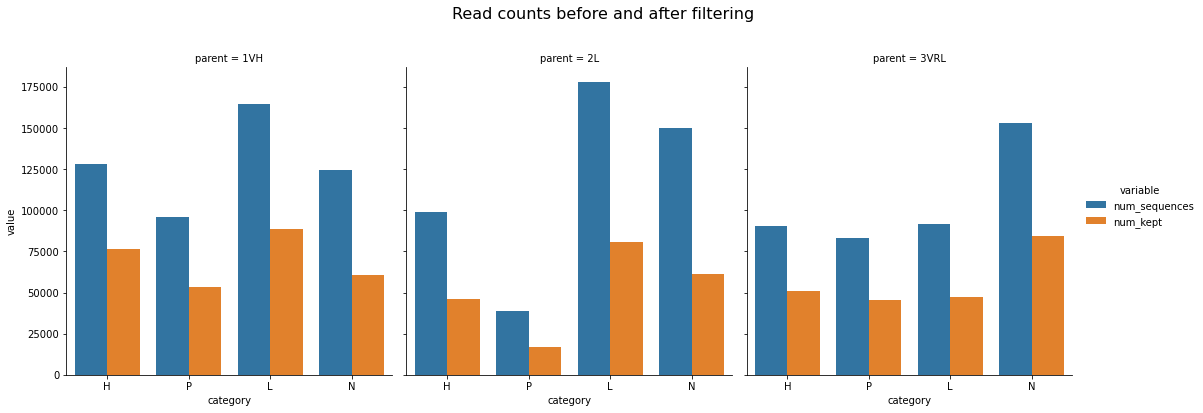

In [44]:
g = sns.catplot(data=samples_melt, x="category", y="value", hue="variable",
            col="parent", kind="bar")

g.fig.suptitle("Read counts before and after filtering", size=16, y=1.1)
pass

In [36]:
# read in all the filtered sequences
value_counts_d = {}
for filename in data_dir.glob("*.tsv"):
    x = pd.read_csv(filename, sep="\t")
    value_counts_d[filename.stem] = x.ss.value_counts()

In [67]:
def add_parent_and_category(barcode, vcs):
    x = vcs.reset_index() # move sequence into columns
    x = x.reset_index() # move sequence ranking into columns
    x["parent"] = samples.loc[barcode].parent
    x["category"] = samples.loc[barcode].category
    return x

In [107]:
all_seqs = pd.concat([add_parent_and_category(barcode, vcs) for barcode, vcs
                       in value_counts_d.items()])
all_seqs["parent"] = pd.Categorical(all_seqs.parent, categories=["1VH", "2L", "3VRL"],
                                    ordered=True)
all_seqs["category"] = pd.Categorical(all_seqs.category, categories=["H", "P", "L", "N"],
                                     ordered=True)
all_seqs

,level_0,index,ss,parent,category
0,0,F152L,20544,2L,H
1,1,"E19K,F152L",2027,2L,H
2,2,"I99V,F152L",1914,2L,H
3,3,"K64R,H129R,F152L,M229I",1911,2L,H
4,4,"Y131H,F152L",1836,2L,H
...,...,...,...,...,...
1017,1017,"M1A,Q2E,H3I,Y5P,P6D,A7K,Q8A,L9F,M10Q,R11D,F12K...",1,1VH,H
1018,1018,"A15S,S117I,D118V,A119M,L120P,D121W,A122M,K123P...",1,1VH,H
1019,1019,"M1K,Q2R,H3A,T4V,Y5S,P6A,A7T,R11*,F12V,G13S,T14...",1,1VH,H
1020,1020,"P200R,E201K,S202A,R203V,A204Q,A205R,L206W,D207...",1,1VH,H


In [111]:
top_3_seqs = all_seqs.drop("level_0", axis="columns").groupby(["parent", "category"]).head(3)

top_3_seqs.sort_values(by=["parent", "category"])

,index,ss,parent,category
0,"A15S,F152L,N198K",19265,1VH,H
1,K227E,17527,1VH,H
2,"P6R,S60G,G86D",16576,1VH,H
0,"A24V,N189D",27651,1VH,P
1,"Q85G,G86*,D87*,K88T,L89G,V90*,S91Q,K92S,A93S,A...",21199,1VH,P
2,"M1R,Q2R,H3*,T4S,Y5P,P6Q,A7Y,Q8A,L9R,M10H,R11T,...",1128,1VH,P
0,*0*,10995,1VH,L
1,"T110S,M258I",1144,1VH,L
2,"M1R,Q2R,H3*,T4S,Y5P,P6Q,A7Y,Q8A,L9R,M10H,R11T,...",1066,1VH,L
0,"D31N,A35G,R141H,M193L",2169,1VH,N


In [102]:
all_seqs.parent.cat.categories

Index(['1VH', '2L', '3VRL'], dtype='object')

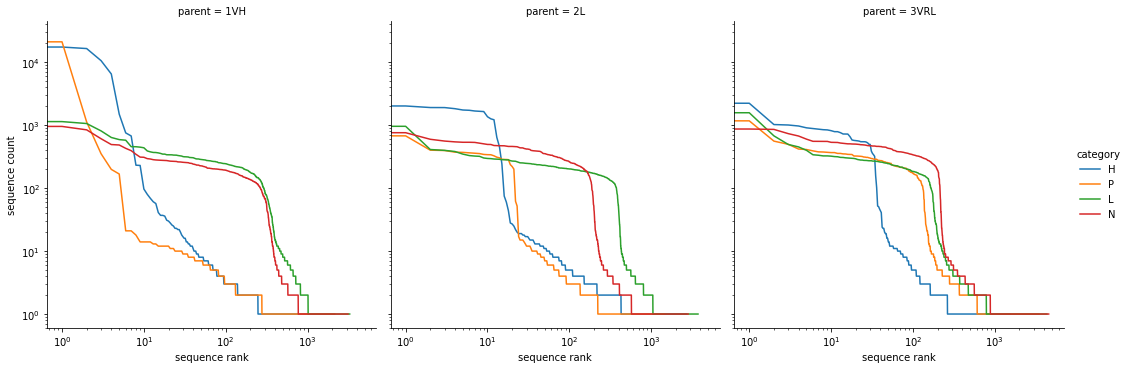

In [86]:
g = sns.relplot(data=all_seqs, x="level_0", y="ss", 
                col="parent", hue="category", kind="line")
g.set(xscale="log", yscale="log", 
      xlabel="sequence rank", ylabel="sequence count")
pass

In [78]:
all_seqs[all_seqs["index"] == "*0*"]

,level_0,index,ss,parent,category
0,0,*0*,10995,1VH,L
2,2,*0*,846,1VH,N
3,3,*0*,10641,1VH,H


In [ ]:
all_seqs[all_seqs["index"] == "*0*"]